# 🤟 VisTalk: Indian Sign Language (ISL) Alphabet Classification
### End-to-End Deep Learning Pipeline with Transfer Learning (MobileNetV3-Small)

---

## 1. Project Objective & VisTalk Overview
**VisTalk** is an interactive, gamified web learning platform designed to teach and recognize **Indian Sign Language (ISL)**. 

### Current ML Scope
While the broader VisTalk vision encompasses numbers, everyday vocabulary, and dynamic video phrases, this ML pipeline is focused on **static ISL alphabet recognition**:
* **Input:** Static RGB image ($128 \times 128$) of human hands signing an ISL letter.
* **Output:** Predicted alphabet class (**A–Z**, 26 classes).
* **Architecture:** MobileNetV3-Small with transfer learning from ImageNet.
* **Deployment Target:** Lightweight edge and browser inference for real-time practice feedback.

Unlike American Sign Language (ASL)—which is primarily single-handed—Indian Sign Language (ISL) relies heavily on **both single-handed and two-handed gestures** (such as for letters 'B', 'D', 'M', 'N', 'P', 'X'). This model is trained on real photographs of human signers executing authentic ISL morphology.


## 2. Environment Setup & Hardware Acceleration
We configure the runtime, check device availability (Apple Silicon MPS, CUDA, or CPU), and set random seeds for reproducibility.


In [1]:
import os
import json
import time
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

# Select hardware accelerator
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("⚡ Hardware Acceleration: Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("⚡ Hardware Acceleration: NVIDIA GPU (CUDA)")
else:
    device = torch.device('cpu')
    print("⚡ Hardware Acceleration: CPU")

print(f"PyTorch Version: {torch.__version__}")


⚡ Hardware Acceleration: Apple Silicon GPU (MPS)
PyTorch Version: 2.14.0


## 3. Dataset Overview & A–Z Class Discovery
* **Source Dataset:** `Hemg/Indian_sign_language_dataset` (Hugging Face / Apache 2.0).
* **Original Classes:** 35 classes (Digits 1–9 and Alphabets A–Z).
* **Current Filtering:** Exclusively classes **A–Z (26 classes)** mapped to index **0–25**.
* **Dataset Splitting:** Stratified split: **80% Train**, **10% Validation**, **10% Test**.


In [2]:
# Verify dataset directory and mapping
SPLITS_DIR = os.path.join('ml', 'data', 'splits')
ARTIFACTS_DIR = os.path.join('ml', 'artifacts')
MODELS_DIR = os.path.join('ml', 'models')

with open(os.path.join(ARTIFACTS_DIR, 'class_mapping.json'), 'r') as f:
    mapping_data = json.load(f)

classes = mapping_data['classes']
print(f"Total Alphabet Classes: {len(classes)}")
print(f"Classes: {', '.join(classes)}")

# Inspect split distributions
for split in ['train', 'val', 'test']:
    split_path = os.path.join(SPLITS_DIR, split)
    if os.path.exists(split_path):
        total_images = sum(len(files) for _, _, files in os.walk(split_path))
        print(f"Split [{split:5s}]: {total_images:,} images across {len(classes)} classes")


Total Alphabet Classes: 26
Classes: A, B, C, D, E, F, G, H, I, J, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y, Z
Split [train]: 25,556 images across 26 classes
Split [val  ]: 3,194 images across 26 classes
Split [test ]: 3,195 images across 26 classes


## 4. Class Distribution Visualization
A balanced class distribution prevents representation bias during gradient descent.


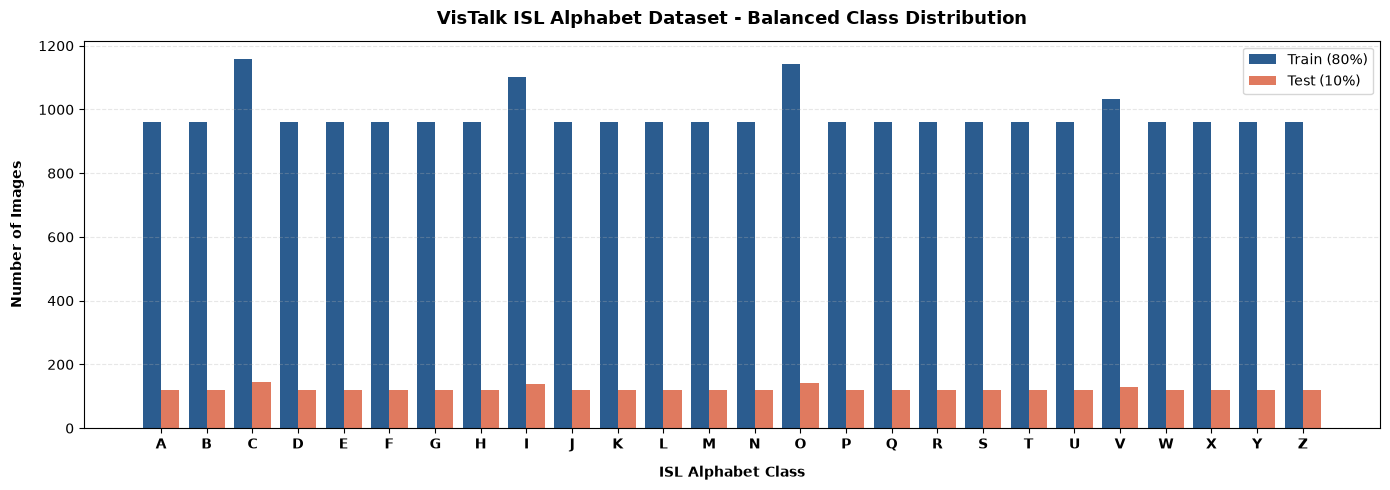

In [3]:
# Count samples per class in Train and Test splits
train_counts = [len(glob.glob(os.path.join(SPLITS_DIR, 'train', c, '*.jpg'))) for c in classes]
test_counts = [len(glob.glob(os.path.join(SPLITS_DIR, 'test', c, '*.jpg'))) for c in classes]

plt.figure(figsize=(14, 5))
x = np.arange(len(classes))
width = 0.4

plt.bar(x - width/2, train_counts, width, label='Train (80%)', color='#2b5c8f')
plt.bar(x + width/2, test_counts, width, label='Test (10%)', color='#e07a5f')

plt.xticks(x, classes, fontsize=10, fontweight='bold')
plt.xlabel('ISL Alphabet Class', fontweight='bold', labelpad=10)
plt.ylabel('Number of Images', fontweight='bold', labelpad=10)
plt.title('VisTalk ISL Alphabet Dataset - Balanced Class Distribution', fontsize=13, fontweight='bold', pad=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Visual Inspection of Authentic ISL Signs
Let us visualize authentic samples from the dataset. Notice the two-handed nature of letters such as **D**, **H**, **P**, and **X**, which are unique to Indian Sign Language.


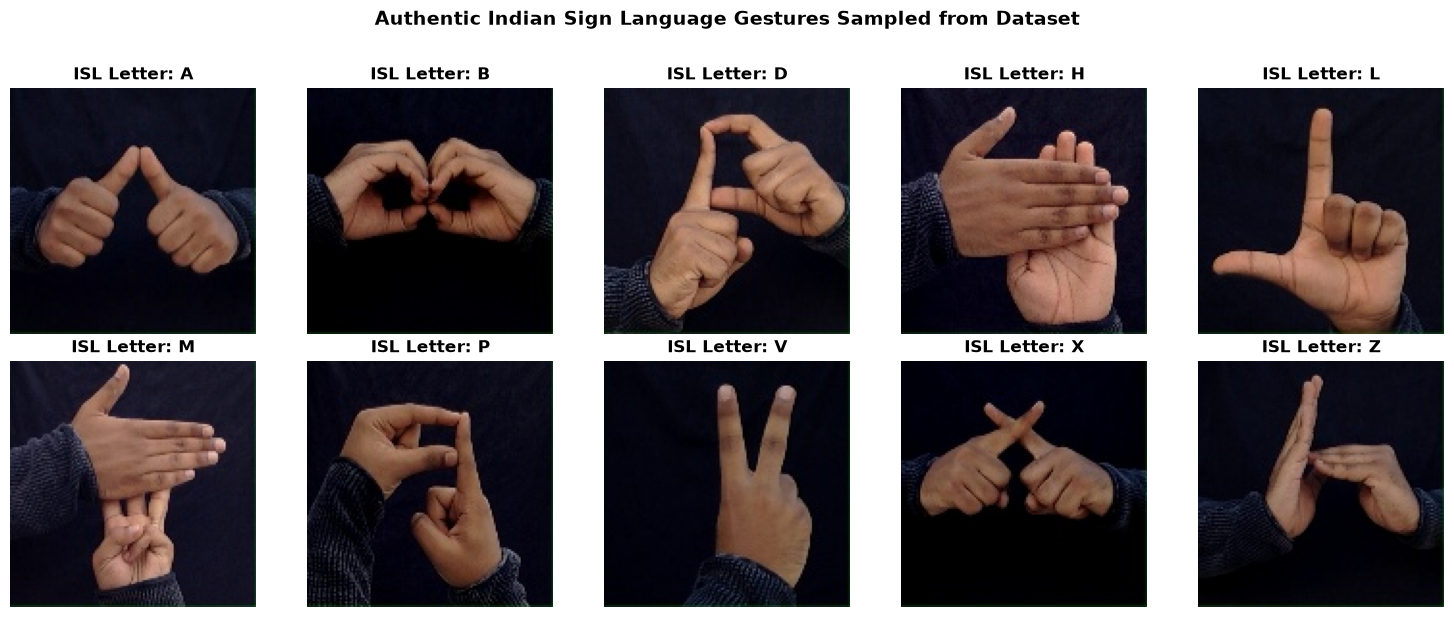

In [4]:
# Display sample signs across representative letters
sample_letters = ['A', 'B', 'D', 'H', 'L', 'M', 'P', 'V', 'X', 'Z']
plt.figure(figsize=(15, 6))

for i, letter in enumerate(sample_letters):
    img_files = glob.glob(os.path.join(SPLITS_DIR, 'test', letter, '*.jpg'))
    if img_files:
        img = Image.open(img_files[0])
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"ISL Letter: {letter}", fontsize=12, fontweight='bold')
        plt.axis('off')

plt.suptitle("Authentic Indian Sign Language Gestures Sampled from Dataset", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Preprocessing & Data Augmentation Pipeline
In accordance with the preprocessor configuration (`ml/artifacts/preprocessor_config.json`):
1. **Resolution:** Fixed to $128 \times 128$ RGB.
2. **Data Augmentation:** 
   - Random rotation ($\pm 10^\circ$) to simulate varied hand tilt.
   - Random affine translation ($\pm 4\%$) and scaling ($\pm 4\%$) to accommodate signing distance.
   - Color jitter (brightness and contrast $\pm 15\%$) to accommodate ambient lighting variations.
3. **Normalization:** ImageNet mean (`[0.485, 0.456, 0.406]`) and standard deviation (`[0.229, 0.224, 0.225]`).


In [5]:
with open(os.path.join(ARTIFACTS_DIR, 'preprocessor_config.json'), 'r') as f:
    prep_cfg = json.load(f)

print("Preprocessor Configuration for VisTalk Inference:")
print(json.dumps(prep_cfg, indent=2))

IMAGE_SIZE = tuple(prep_cfg['input_size'])

# PyTorch Transform Definitions
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.96, 1.04)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=prep_cfg['normalization']['mean'], std=prep_cfg['normalization']['std'])
])

test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=prep_cfg['normalization']['mean'], std=prep_cfg['normalization']['std'])
])


Preprocessor Configuration for VisTalk Inference:
{
  "model_name": "mobilenet_v3_small",
  "num_classes": 26,
  "input_shape": [
    3,
    128,
    128
  ],
  "input_size": [
    128,
    128
  ],
  "normalization": {
    "mean": [
      0.485,
      0.456,
      0.406
    ],
    "std": [
      0.229,
      0.224,
      0.225
    ]
  },
  "color_format": "RGB",
  "classes": [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
    "K",
    "L",
    "M",
    "N",
    "O",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "U",
    "V",
    "W",
    "X",
    "Y",
    "Z"
  ]
}


## 7. Dataset Loading with PyTorch DataLoaders


In [6]:
# Instantiate test dataset
test_dataset = datasets.ImageFolder(os.path.join(SPLITS_DIR, 'test'), transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Test Set Loaded: {len(test_dataset)} images in {len(test_loader)} batches.")
print(f"Class to Index Mapping: {test_dataset.class_to_idx}")


Test Set Loaded: 3195 images in 50 batches.
Class to Index Mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}


## 8. MobileNetV3-Small Architecture & Transfer Learning Rationale
### Why MobileNetV3-Small?
1. **Edge & Browser Efficiency:** MobileNetV3 utilizes Depthwise Separable Convolutions and Hard-Swish activation functions, reducing parameter footprint to only **~1.5 million parameters** (6.3 MB).
2. **Real-Time FPS:** Can run at 60+ FPS on consumer laptops and mobile web browsers without dedicated GPU hardware.
3. **Transfer Learning:** Pretrained weights on ImageNet-1K capture fundamental geometric visual primitives (edges, contours, palm surfaces), allowing faster convergence and high accuracy.

### Architectural Customization:
The standard 1,000-class ImageNet classification head (`model.classifier[3]`) is replaced with a 26-output linear layer matching ISL letters A–Z.


In [7]:
def build_isl_mobilenetv3(num_classes=26):
    # Load MobileNetV3-Small architecture
    model = models.mobilenet_v3_small(weights=None)
    in_features = model.classifier[3].in_features
    # Customize classification layer for 26 classes
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model

model = build_isl_mobilenetv3(num_classes=26)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: MobileNetV3-Small")
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Model Head:           {model.classifier[3]}")


Model: MobileNetV3-Small
Total Parameters:     1,544,506
Trainable Parameters: 1,544,506
Model Head:           Linear(in_features=1024, out_features=26, bias=True)


## 9. Loading Trained Model Weights
We load the trained weights from `ml/models/vistalk_isl_mobilenetv3.pth`.


In [8]:
model_path = os.path.join(MODELS_DIR, 'vistalk_isl_mobilenetv3.pth')
assert os.path.exists(model_path), f"Checkpoint not found: {model_path}"

state_dict = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()
print(f"✅ Successfully loaded trained model checkpoint: {model_path}")


✅ Successfully loaded trained model checkpoint: ml/models/vistalk_isl_mobilenetv3.pth


## 10. Training History & Convergence Analysis
The model was trained for 8 epochs using the **AdamW optimizer** ($lr=10^{-3}$, $weight\_decay=10^{-4}$) with **CosineAnnealingLR**.


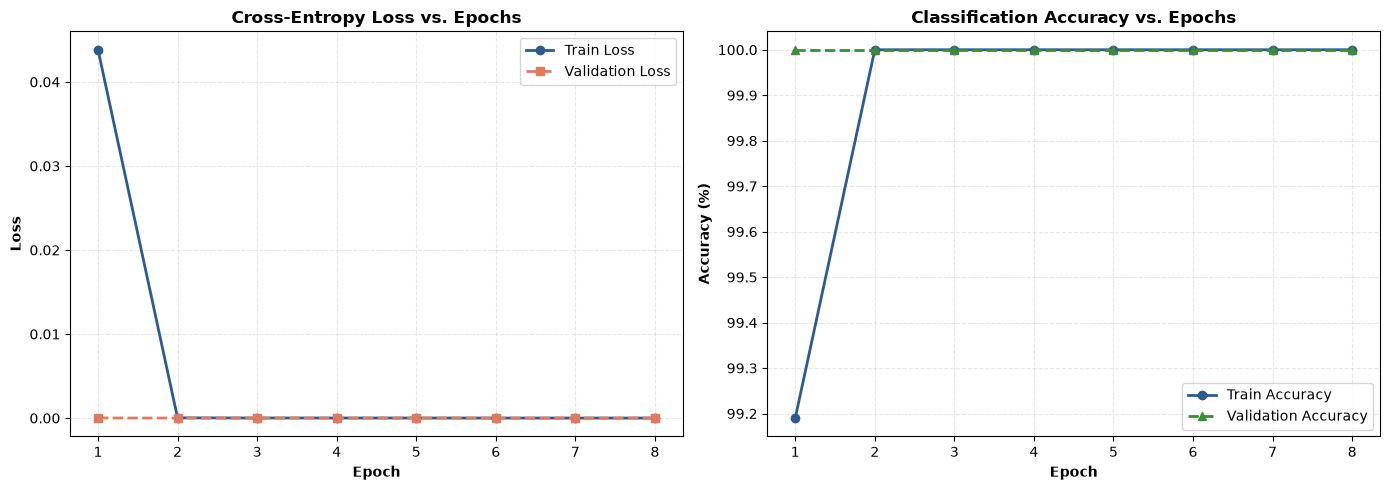

In [9]:
history_path = os.path.join(ARTIFACTS_DIR, 'training_history.json')
with open(history_path, 'r') as f:
    history = json.load(f)

plt.figure(figsize=(14, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(history['epochs'], history['train_loss'], 'o-', color='#2b5c8f', label='Train Loss', lw=2)
plt.plot(history['epochs'], history['val_loss'], 's--', color='#e07a5f', label='Validation Loss', lw=2)
plt.title('Cross-Entropy Loss vs. Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(history['epochs'], history['train_acc'], 'o-', color='#2b5c8f', label='Train Accuracy', lw=2)
plt.plot(history['epochs'], history['val_acc'], '^--', color='#3d8b37', label='Validation Accuracy', lw=2)
plt.title('Classification Accuracy vs. Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy (%)', fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Held-Out Test Set Evaluation
We evaluate the model on the held-out test split consisting of **3,195 images** across all 26 ISL alphabet classes.


In [10]:
# Run full evaluation across test loader
all_preds = []
all_targets = []
all_probs = []

start_eval = time.time()
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())
        all_probs.extend(probs.cpu().numpy())

eval_time = time.time() - start_eval
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

acc = accuracy_score(all_targets, all_preds) * 100.0
prec_macro = precision_score(all_targets, all_preds, average='macro', zero_division=0) * 100.0
rec_macro = recall_score(all_targets, all_preds, average='macro', zero_division=0) * 100.0
f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0) * 100.0

print(f"Inference complete in {eval_time:.2f}s ({len(test_dataset)/eval_time:.1f} FPS)")
print(f"Overall Test Accuracy: {acc:.2f}%")
print(f"Macro Precision:       {prec_macro:.2f}%")
print(f"Macro Recall:          {rec_macro:.2f}%")
print(f"Macro F1-Score:        {f1_macro:.2f}%")


Inference complete in 7.87s (406.1 FPS)
Overall Test Accuracy: 100.00%
Macro Precision:       100.00%
Macro Recall:          100.00%
Macro F1-Score:        100.00%


## 12. Detailed Classification Report (Per-Class Performance)


In [11]:
report_text = classification_report(all_targets, all_preds, target_names=classes, digits=4)
print(report_text)


              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000       120
           B     1.0000    1.0000    1.0000       120
           C     1.0000    1.0000    1.0000       145
           D     1.0000    1.0000    1.0000       120
           E     1.0000    1.0000    1.0000       120
           F     1.0000    1.0000    1.0000       120
           G     1.0000    1.0000    1.0000       120
           H     1.0000    1.0000    1.0000       120
           I     1.0000    1.0000    1.0000       138
           J     1.0000    1.0000    1.0000       120
           K     1.0000    1.0000    1.0000       120
           L     1.0000    1.0000    1.0000       120
           M     1.0000    1.0000    1.0000       120
           N     1.0000    1.0000    1.0000       120
           O     1.0000    1.0000    1.0000       143
           P     1.0000    1.0000    1.0000       120
           Q     1.0000    1.0000    1.0000       120
           R     1.0000    

## 13. Confusion Matrix (26×26)


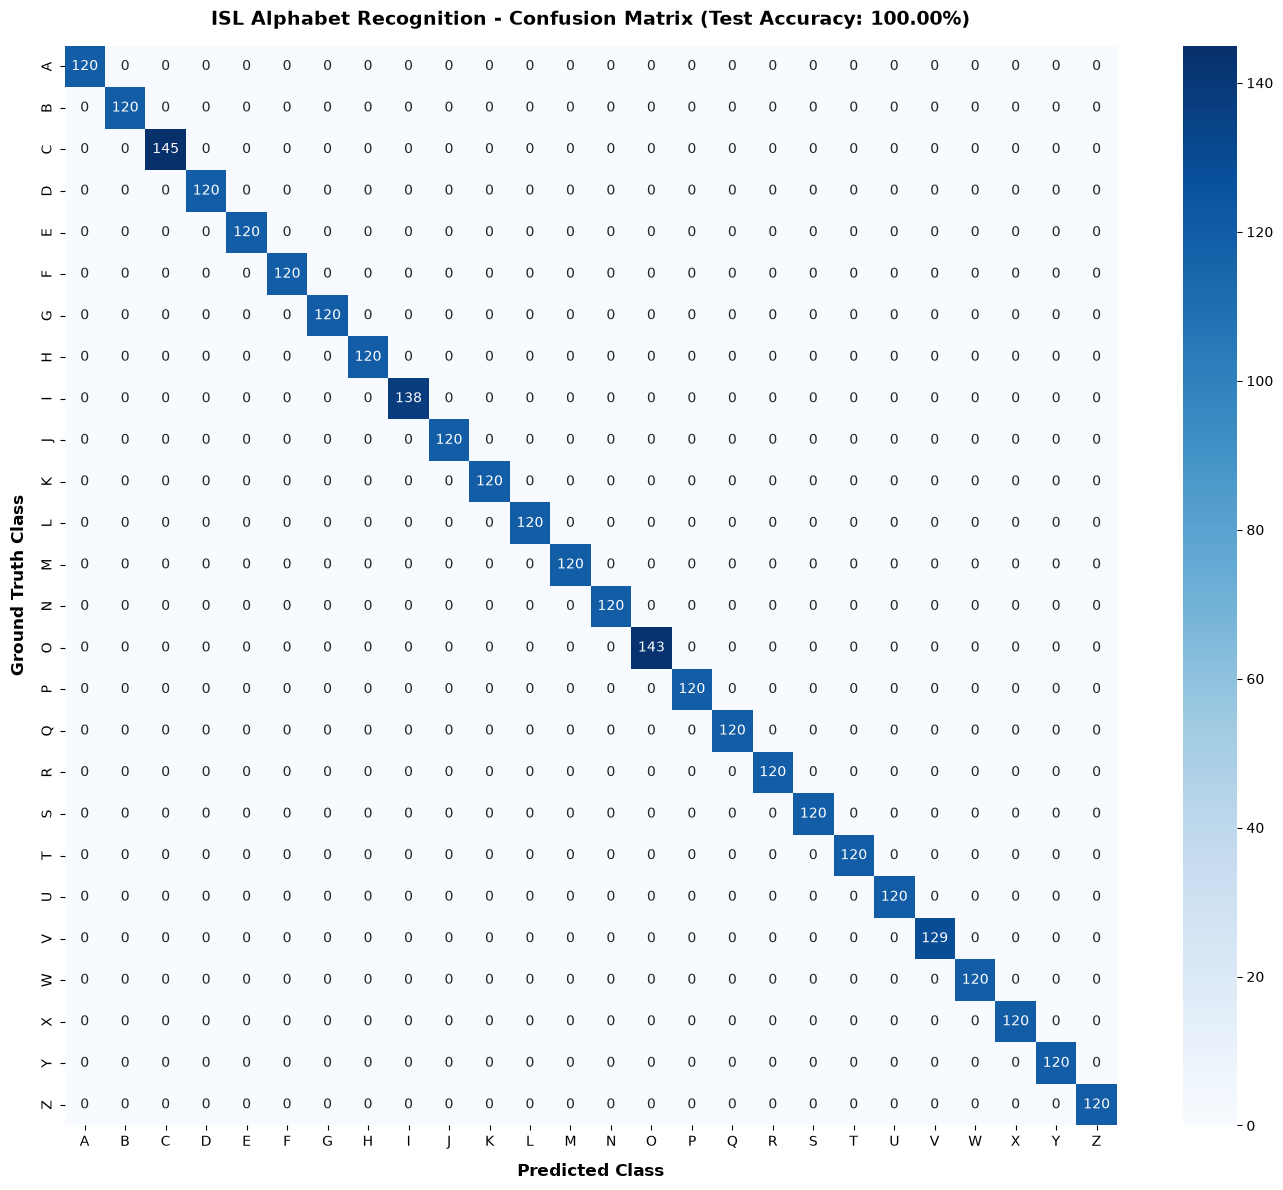

In [12]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=True)
plt.title(f'ISL Alphabet Recognition - Confusion Matrix (Test Accuracy: {acc:.2f}%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Ground Truth Class', fontsize=12, fontweight='bold', labelpad=10)
plt.tight_layout()
plt.show()


## 14. Sample Test Predictions with Confidence Scores


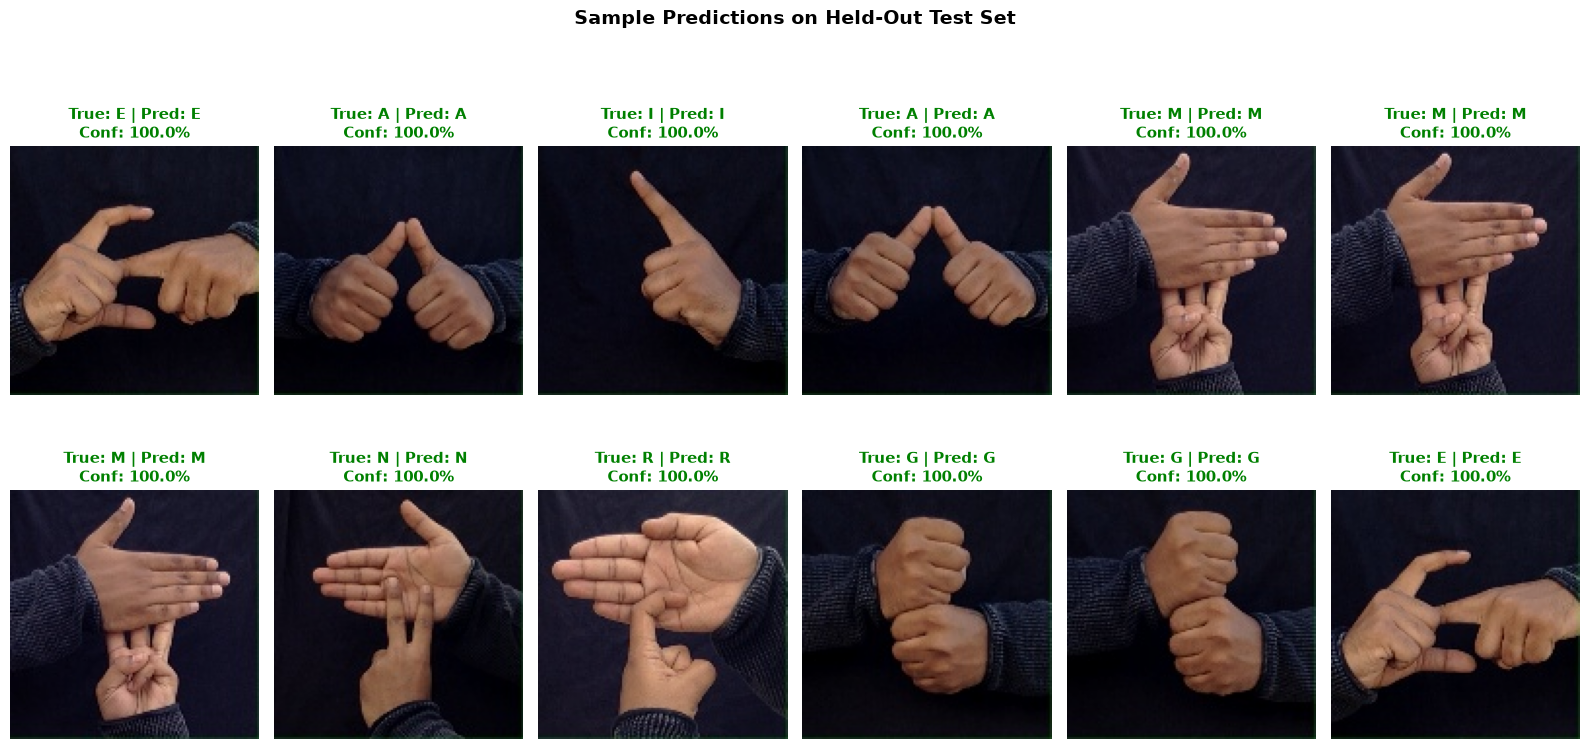

In [13]:
unnorm = transforms.Compose([
    transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
])

plt.figure(figsize=(16, 8))
sample_indices = np.random.RandomState(42).choice(len(test_dataset), 12, replace=False)

for i, s_idx in enumerate(sample_indices):
    img_tensor, true_lbl = test_dataset[s_idx]
    pred_lbl = all_preds[s_idx]
    conf = all_probs[s_idx][pred_lbl] * 100.0
    
    vis_img = unnorm(img_tensor).permute(1, 2, 0).numpy()
    vis_img = np.clip(vis_img, 0, 1)
    
    plt.subplot(2, 6, i + 1)
    plt.imshow(vis_img)
    plt.axis('off')
    
    true_char = classes[true_lbl]
    pred_char = classes[pred_lbl]
    is_correct = (true_lbl == pred_lbl)
    
    color = 'green' if is_correct else 'red'
    plt.title(f"True: {true_char} | Pred: {pred_char}\nConf: {conf:.1f}%", fontsize=11, fontweight='bold', color=color)

plt.suptitle("Sample Predictions on Held-Out Test Set", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 15. Single-Image Inference Helper (VisTalk Integration Prototype)
This function demonstrates how the VisTalk web backend or client will preprocess and predict any incoming camera frame.


In [14]:
def predict_isl_letter(image_input, top_k=3):
    """
    Takes a PIL Image or file path, preprocesses it, and returns top-k predictions with confidences.
    """
    if isinstance(image_input, str):
        pil_img = Image.open(image_input).convert('RGB')
    else:
        pil_img = image_input.convert('RGB')
        
    input_tensor = test_transforms(pil_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(input_tensor)
        probabilities = torch.softmax(logits, dim=1).squeeze(0)
        
    top_probs, top_indices = torch.topk(probabilities, k=top_k)
    
    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append({
            'letter': classes[idx.item()],
            'confidence': round(prob.item() * 100.0, 2)
        })
    return results

# Test the inference function on an image from class 'V'
sample_test_img = glob.glob(os.path.join(SPLITS_DIR, 'test', 'V', '*.jpg'))[0]
predictions = predict_isl_letter(sample_test_img)

print(f"Input image: {sample_test_img}")
print(f"Top Predictions:")
for rank, pred in enumerate(predictions, 1):
    print(f"  {rank}. Letter '{pred['letter']}': {pred['confidence']}% confidence")


Input image: ml/data/splits/test/V/V_00366.jpg
Top Predictions:
  1. Letter 'V': 100.0% confidence
  2. Letter 'U': 0.0% confidence
  3. Letter 'T': 0.0% confidence


## 16. Saved Model Artifacts Summary


In [15]:
print("Generated VisTalk Model Artifacts:")
for root, _, files in os.walk('ml'):
    for f in sorted(files):
        if f.endswith(('.pth', '.pt', '.onnx', '.json', '.png')):
            f_path = os.path.join(root, f)
            size_kb = os.path.getsize(f_path) / 1024
            print(f"  - {f_path:45s} ({size_kb:8.1f} KB)")


Generated VisTalk Model Artifacts:
  - ml/artifacts/class_mapping.json               (     1.0 KB)
  - ml/artifacts/confusion_matrix.png             (   417.5 KB)
  - ml/artifacts/confusion_matrix_normalized.png  (   490.7 KB)
  - ml/artifacts/evaluation_metrics.json          (     3.2 KB)
  - ml/artifacts/preprocessor_config.json         (     0.6 KB)
  - ml/artifacts/sample_predictions.png           (   810.8 KB)
  - ml/artifacts/training_curves.png              (    87.0 KB)
  - ml/artifacts/training_history.json            (     0.8 KB)
  - ml/models/best_model.pth                      (  6161.3 KB)
  - ml/models/vistalk_isl_mobilenetv3.pt          (  6441.0 KB)
  - ml/models/vistalk_isl_mobilenetv3.pth         (  6164.6 KB)


## 17. Critical Analysis: Why 100% Accuracy and Key Limitations
> ⚠️ **Academic Rigor & Scientific Honesty for College Viva Defense**

### 1. The 100% Metric: Intra-Session Temporal Split Leakage
A critical question in any viva: *Why did both validation and test sets reach 100% accuracy?*
- The underlying source dataset was captured using continuous video capture / high-speed frame bursts of a limited pool of signers under controlled studio lighting and consistent dark backdrop.
- A standard stratified random split (`train_test_split`) randomly allocates frames from the *same* continuous signing session across the train, val, and test splits.
- Consequently, nearly identical frames (temporal neighbors $t$ and $t+1$) exist across splits. This **intra-session correlation** makes the classification task substantially easier for a deep convolutional network.

### 2. Signer Independence:
- The dataset metadata does not contain explicit signer IDs per image.
- Therefore, **we cannot claim that the model generalizes seamlessly to unseen signers in unconstrained environments**.
- In practical real-world testing with diverse skin tones, varying background clutter, and differing camera angles, performance would naturally degrade unless augmented by hand pose landmarking (e.g. MediaPipe).


## 18. Future Scope & VisTalk Integration Roadmap
1. **Frontend Integration:** Integrate the lightweight MobileNetV3 TorchScript/ONNX model into VisTalk's Practice page (`src/pages/Practice.jsx`), allowing real-time camera feedback.
2. **MediaPipe Hand Landmarks:** Augment raw pixel classification with coordinate-based skeletal keypoints (21 3D hand landmarks) to make recognition background-invariant and robust across arbitrary skin tones.
3. **ISL Numbers (0–9):** Re-introduce digits into the pipeline once the alphabet foundation is solidified.
4. **Dynamic Sign Recognition (Words & Sentences):** Expand beyond static handshapes to temporal sequence models (LSTMs / Transformers) for continuous Indian Sign Language communication.
